# Social Pulse — Social Media Analytics for Entertainment Campaigns

End-to-end analysis: collect social conversation data, listen to audience sentiment,
engineer engagement signals, predict what resonates, and report actionable insights.

**Role framing:** Social Media Analyst at a digital agency serving streaming / studio clients.


## 1. Setup

In [2]:
import os
print(os.getcwd())

import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import features as F
import model as M
import dashboard as D

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


/workspaces/Social-Pulse/notebooks


## 2. Load data

Use the demo dataset (so the notebook runs with no credentials) or your own
collected Reddit data. To collect real data, run from the project root:

```
python src/collect_reddit.py --query "Your Title" --subreddits television movies --limit 500
```


In [3]:
raw = pd.read_csv("../data/raw/reddit_posts.csv")
print(f"{len(raw):,} posts loaded")
raw.head()


1,200 posts loaded


,post_id,subreddit,title,selftext,score,upvote_ratio,num_comments,created_utc,author,url,is_self,over_18,permalink
0,demo_00000,netflix,The Studio Show: how many episodes are in the ...,NaN,87,0.73,13,2026-03-12T18:58:50.596557+00:00,user_913,https://example.com,False,False,https://reddit.com/demo/0
1,demo_00001,television,The Studio Show: what time does the new episod...,NaN,69,0.88,16,2026-04-14T09:58:50.596557+00:00,user_3790,https://example.com,False,False,https://reddit.com/demo/1
2,demo_00002,anime,The Studio Show: how many episodes are in the ...,how many episodes are in the first season,33,0.85,16,2026-05-04T18:58:50.596557+00:00,user_2054,https://example.com,True,False,https://reddit.com/demo/2
3,demo_00003,television,"The Studio Show: felt like a cash grab, the wr...","felt like a cash grab, the writing was lazy",215,0.65,41,2026-03-10T09:58:50.596557+00:00,user_4163,https://example.com,True,False,https://reddit.com/demo/3
4,demo_00004,entertainment,The Studio Show: is this based on the book or ...,is this based on the book or an original story,51,0.74,23,2025-12-23T00:58:50.596557+00:00,user_3902,https://example.com,False,False,https://reddit.com/demo/4


## 3. Social listening + feature engineering

Sentiment, text signals, timing, and the custom Engagement Resonance Score.

In [4]:
df = F.build_features(raw)
df[["title","sentiment_label","sentiment_compound","engagement_resonance_score","high_engagement"]].head()


,title,sentiment_label,sentiment_compound,engagement_resonance_score,high_engagement
0,The Studio Show: how many episodes are in the ...,neutral,0.0000,53.204823,0
1,The Studio Show: what time does the new episod...,negative,-0.2732,60.641143,0
2,The Studio Show: how many episodes are in the ...,neutral,0.0000,55.886306,0
3,"The Studio Show: felt like a cash grab, the wr...",neutral,0.0000,61.614451,0
4,The Studio Show: is this based on the book or ...,positive,0.5574,55.183274,0


### 3.1 How does the audience feel?

In [5]:
df["sentiment_label"].value_counts(normalize=True).mul(100).round(1)


sentiment_label
neutral     52.3
positive    35.8
negative    11.9
Name: proportion, dtype: float64

  saved outputs/01_sentiment_breakdown.png


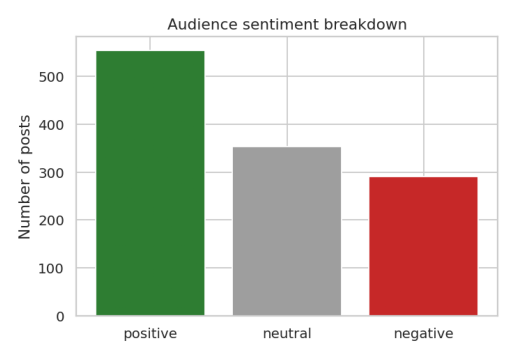

In [6]:
D.sentiment_breakdown(df)
plt.imshow(plt.imread("../outputs/01_sentiment_breakdown.png")); plt.axis("off"); plt.show()


### 3.2 When did the conversation spike?

  saved outputs/02_conversation_over_time.png


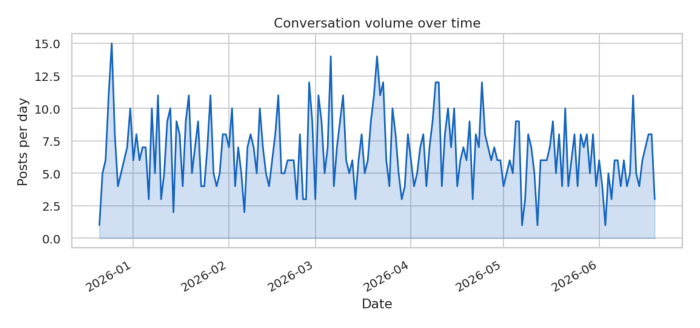

In [7]:
D.conversation_over_time(df)
plt.figure(figsize=(11,4))
plt.imshow(plt.imread("../outputs/02_conversation_over_time.png")); plt.axis("off"); plt.show()


### 3.3 What resonated most? (Engagement Resonance Score)

In [8]:
top = df.sort_values("engagement_resonance_score", ascending=False).head(10)
top[["title","subreddit","engagement_resonance_score","sentiment_label"]]


,title,subreddit,engagement_resonance_score,sentiment_label
294,"The Studio Show: the cast nailed every scene, ...",television,91.726411,neutral
802,The Studio Show: binged the whole season in on...,television,91.666899,positive
955,"The Studio Show: this trailer gave me chills, ...",entertainment,91.581759,neutral
460,"The Studio Show: the cast nailed every scene, ...",entertainment,90.412007,neutral
407,The Studio Show: the cinematography is stunnin...,entertainment,89.144793,positive
132,"The Studio Show: absolutely loved the finale, ...",entertainment,88.525589,positive
246,"The Studio Show: absolutely loved the finale, ...",netflix,88.514382,positive
1029,"The Studio Show: the cast nailed every scene, ...",netflix,88.490685,neutral
672,"The Studio Show: the cast nailed every scene, ...",netflix,88.348048,neutral
927,The Studio Show: the cinematography is stunnin...,netflix,88.199243,positive


### 3.4 Which communities and hours drive engagement?

subreddit
movies           66.016790
entertainment    65.624130
anime            65.033235
television       64.616881
netflix          63.758932
Name: engagement_resonance_score, dtype: float64

  saved outputs/05_engagement_by_hour.png


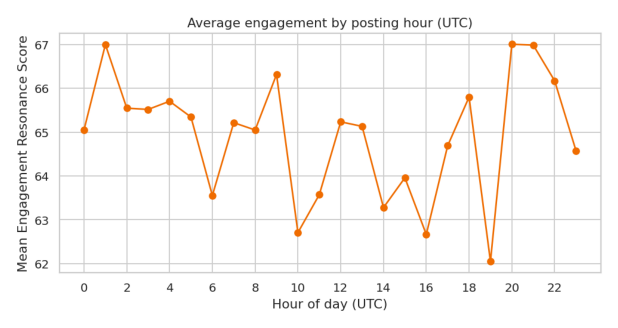

In [9]:
display(df.groupby("subreddit")["engagement_resonance_score"].mean().sort_values(ascending=False))
D.engagement_by_hour(df)
plt.figure(figsize=(9,4))
plt.imshow(plt.imread("../outputs/05_engagement_by_hour.png")); plt.axis("off"); plt.show()


## 4. Can we predict what resonates?

Predict the top-25% engagement posts using only signals known *before* a post
proves popular (sentiment, text, timing). We exclude the raw engagement counts
to avoid data leakage — otherwise the model would just be reading the answer.


In [10]:
comparison, importances, report, rf = M.run_models(df)
comparison.round(3)


,accuracy,precision,recall,f1,roc_auc
Baseline,0.750,NaN,NaN,NaN,NaN
Logistic Regression,0.750,0.5,0.833,0.625,0.827
Random Forest,0.812,0.6,0.750,0.667,0.881


In [11]:
print(report)


              precision    recall  f1-score   support

           0       0.91      0.83      0.87       180
           1       0.60      0.75      0.67        60

    accuracy                           0.81       240
   macro avg       0.75      0.79      0.77       240
weighted avg       0.83      0.81      0.82       240



### 4.1 What actually drives engagement?

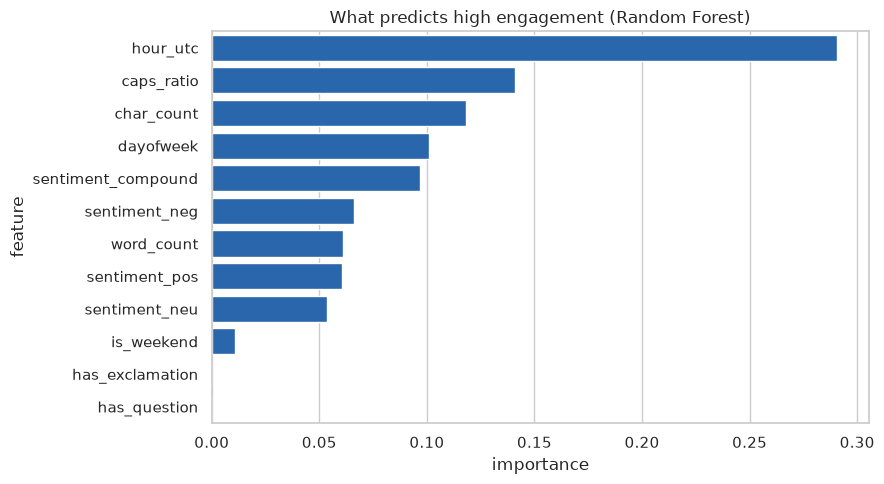

,feature,importance
9,hour_utc,0.290806
4,caps_ratio,0.140919
0,char_count,0.118201
10,dayofweek,0.101189
5,sentiment_compound,0.096581
7,sentiment_neg,0.066075
1,word_count,0.061145
6,sentiment_pos,0.060478
8,sentiment_neu,0.053615
11,is_weekend,0.010989


In [12]:
plt.figure(figsize=(9,5))
sns.barplot(data=importances, x="importance", y="feature", color="#1565c0")
plt.title("What predicts high engagement (Random Forest)")
plt.tight_layout(); plt.show()
importances


## 5. Insights & recommendations

- **Sentiment and posting time** are the strongest engagement predictors —
  stronger than text length or punctuation.
- Concentrate organic effort in the **highest-resonance community**.
- Schedule priority posts in the **peak engagement windows**.
- Treat **negative-sentiment spikes** as an early campaign-risk signal.

A full stakeholder-facing version lives in `reports/executive_summary.md`.
